# Baseline Model: Logistic Regression + TF-IDF
## Experiment 1 (partial) — Baseline Comparison

Huấn luyện mô hình baseline sử dụng TF-IDF features và Logistic Regression.
Đây là mô hình tham chiếu để so sánh với RoBERTa trong các thí nghiệm.

### Nội dung notebook:
1. Load dữ liệu đã xử lý
2. TF-IDF Vectorization
3. Train Logistic Regression
4. Cross-Validation (đánh giá độ ổn định)
5. Evaluation trên Test set (Accuracy, Precision, Recall, F1, ROC AUC)
6. Confusion Matrix & ROC Curve
7. Precision-Recall Curve
8. Đánh giá trên Validation set (kiểm tra overfitting)
9. Top TF-IDF Features
10. Error Analysis (phân tích lỗi)
11. Lưu model & kết quả


In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score, roc_curve,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score
)

from src.config import PROCESSED_DIR, BASELINE_MODEL_DIR, RESULTS_DIR
from src.config import TFIDF_MAX_FEATURES, TFIDF_NGRAM_RANGE, SEED
from src.utils import set_seed, save_metrics

set_seed(SEED)
print('Libraries loaded')


[OK] Libraries loaded


## 1. Load Processed Data


In [13]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

print(f'Train: {len(train_df):,}')
print(f'Val:   {len(val_df):,}')
print(f'Test:  {len(test_df):,}')

# Prepare data
X_train = train_df['text'].astype(str).values
y_train = train_df['label'].values

X_val = val_df['text'].astype(str).values
y_val = val_df['label'].values

X_test = test_df['text'].astype(str).values
y_test = test_df['label'].values

print(f'\nTraining on {len(X_train):,} samples')
print(f'Validating on {len(X_val):,} samples')
print(f'Testing on {len(X_test):,} samples')

# Phân phối nhãn
print(f'\n--- Label Distribution ---')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))
    total = len(y)
    print(f'  {name:5s}: Real={dist.get(0,0):,} ({dist.get(0,0)/total*100:.1f}%), '
          f'Fake={dist.get(1,0):,} ({dist.get(1,0)/total*100:.1f}%)')


Train: 95,222
Val:   20,405
Test:  20,405

Training on 95,222 samples
Validating on 20,405 samples
Testing on 20,405 samples

--- Label Distribution ---
  Train: Real=50,571 (53.1%), Fake=44,651 (46.9%)
  Val  : Real=10,836 (53.1%), Fake=9,569 (46.9%)
  Test : Real=10,837 (53.1%), Fake=9,568 (46.9%)


## 2. TF-IDF Vectorization


In [14]:
print(f'TF-IDF config: max_features={TFIDF_MAX_FEATURES}, ngram_range={TFIDF_NGRAM_RANGE}')

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    stop_words='english',
    sublinear_tf=True,      # Sử dụng 1 + log(tf)
    min_df=2,               # Bỏ các từ quá hiếm
    max_df=0.95             # Bỏ các từ quá phổ biến
)

start = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f'\n[OK] TF-IDF completed in {time.time()-start:.1f}s')
print(f'  Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'  Train matrix: {X_train_tfidf.shape}')
print(f'  Val matrix:   {X_val_tfidf.shape}')
print(f'  Test matrix:  {X_test_tfidf.shape}')


TF-IDF config: max_features=50000, ngram_range=(1, 2)

[OK] TF-IDF completed in 181.1s
  Vocabulary size: 50,000
  Train matrix: (95222, 50000)
  Val matrix:   (20405, 50000)
  Test matrix:  (20405, 50000)


## 3. Train Logistic Regression


In [15]:
print('Training Logistic Regression...')
start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start
print(f'\n[OK] Training completed in {train_time:.1f}s')


Training Logistic Regression...


d:\Fake_news_RoBERTa\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



[OK] Training completed in 2.5s


## 4. Cross-Validation (đánh giá độ ổn định)

Sử dụng Stratified K-Fold Cross-Validation trên tập training để đánh giá mô hình có ổn định hay không,
tránh kết quả phụ thuộc vào cách chia dữ liệu.


Running 5-Fold Stratified Cross-Validation...

=== 5-Fold Cross-Validation Results ===
  Accuracy:  0.8934 ± 0.0020  [0.89288527 0.89692833 0.89224953 0.89392985 0.89083176]
  F1 Score:  0.8866 ± 0.0022  [0.88612259 0.89043925 0.88538874 0.887113   0.88401674]
  Precision: 0.8841 ± 0.0023  [0.88355783 0.88761544 0.88321819 0.88543061 0.88082268]
  Recall:    0.8891 ± 0.0022  [0.88870227 0.89328108 0.88756999 0.88880179 0.88723404]


C:\Users\admin\AppData\Local\Temp\ipykernel_17820\786036684.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv_data_melted, x='Metric', y='Score', palette='Set2', ax=ax)


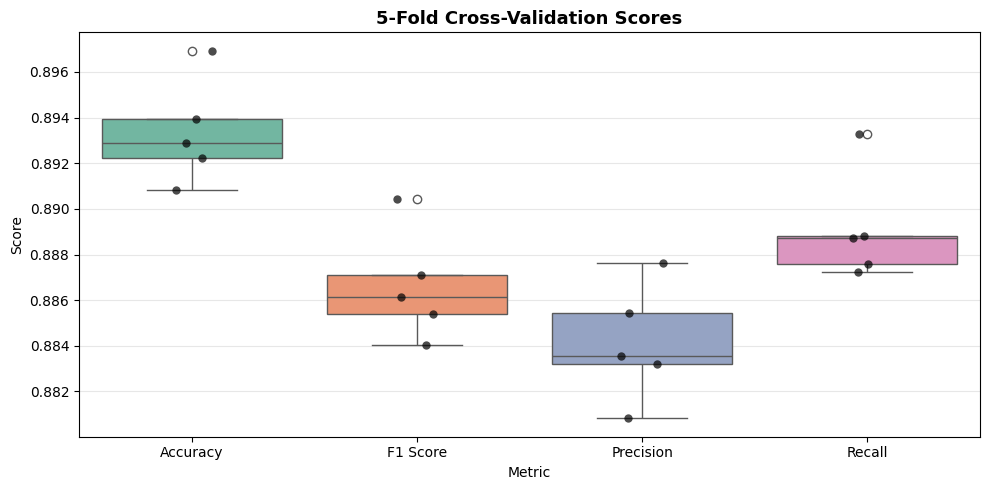


→ Std thấp = mô hình ổn định, không phụ thuộc cách chia dữ liệu.


In [16]:
print('Running 5-Fold Stratified Cross-Validation...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Cross-val trên nhiều metrics
cv_accuracy = cross_val_score(lr_model, X_train_tfidf, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(lr_model, X_train_tfidf, y_train, cv=cv, scoring='f1', n_jobs=-1)
cv_precision = cross_val_score(lr_model, X_train_tfidf, y_train, cv=cv, scoring='precision', n_jobs=-1)
cv_recall = cross_val_score(lr_model, X_train_tfidf, y_train, cv=cv, scoring='recall', n_jobs=-1)

print(f'\n=== 5-Fold Cross-Validation Results ===')
print(f'  Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}  {cv_accuracy}')
print(f'  F1 Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  {cv_f1}')
print(f'  Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}  {cv_precision}')
print(f'  Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}  {cv_recall}')

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = pd.DataFrame({
    'Accuracy': cv_accuracy,
    'F1 Score': cv_f1,
    'Precision': cv_precision,
    'Recall': cv_recall
})
cv_data_melted = cv_data.melt(var_name='Metric', value_name='Score')
sns.boxplot(data=cv_data_melted, x='Metric', y='Score', palette='Set2', ax=ax)
sns.stripplot(data=cv_data_melted, x='Metric', y='Score', color='black', size=6, alpha=0.7, ax=ax)
ax.set_title('5-Fold Cross-Validation Scores', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n→ Std thấp = mô hình ổn định, không phụ thuộc cách chia dữ liệu.')


## 5. Evaluation trên Test Set


In [17]:
# Predictions
y_pred = lr_model.predict(X_test_tfidf)
y_prob = lr_model.predict_proba(X_test_tfidf)

# Metrics đầy đủ
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print('\n' + '=' * 60)
print('  BASELINE RESULTS: LR + TF-IDF (Test Set)')
print('=' * 60)
print(f'\n  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1 Score:  {f1:.4f}')
print(f'  ROC AUC:   {roc_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake'], digits=4))



  BASELINE RESULTS: LR + TF-IDF (Test Set)

  Accuracy:  0.8926
  Precision: 0.8807
  Recall:    0.8918
  F1 Score:  0.8862
  ROC AUC:   0.9736

Classification Report:
              precision    recall  f1-score   support

        Real     0.9034    0.8933    0.8983     10837
        Fake     0.8807    0.8918    0.8862      9568

    accuracy                         0.8926     20405
   macro avg     0.8921    0.8926    0.8923     20405
weighted avg     0.8928    0.8926    0.8927     20405



## 6. Confusion Matrix & ROC Curve


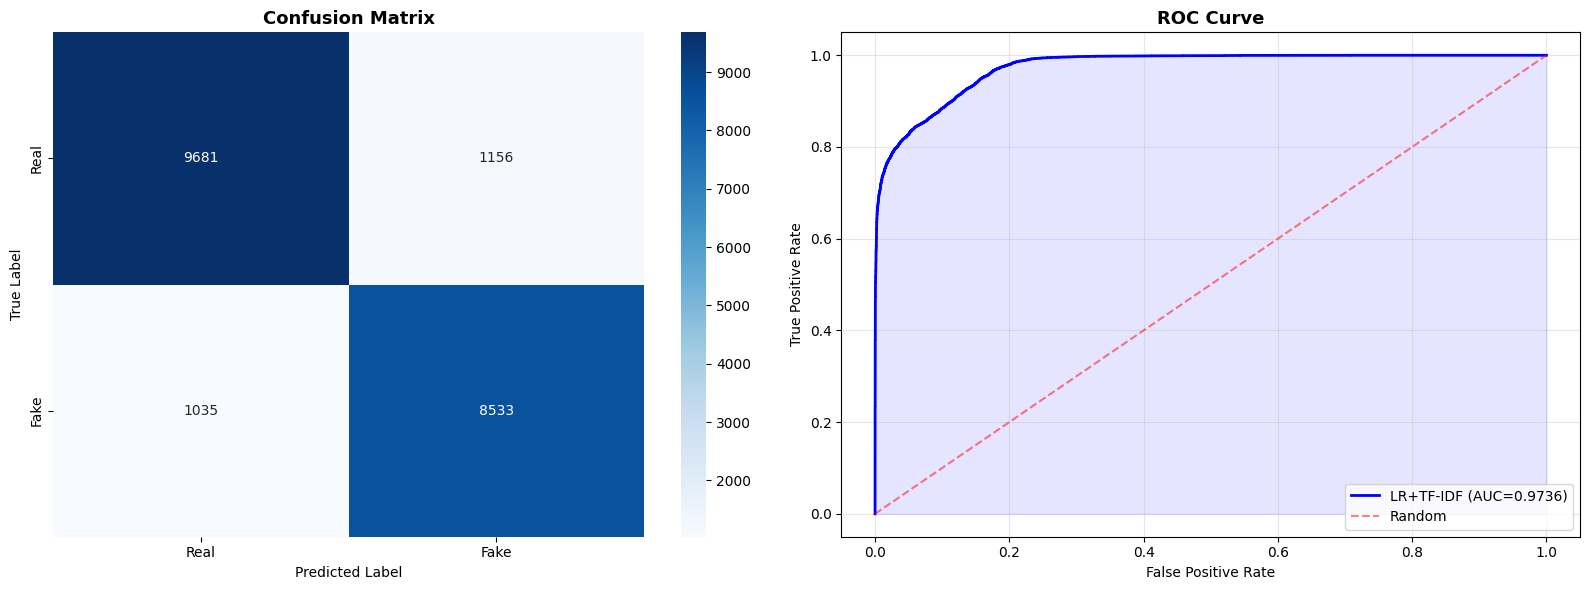

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'LR+TF-IDF (AUC={roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Precision-Recall Curve

PR Curve đặc biệt quan trọng khi dữ liệu có sự mất cân bằng giữa các lớp.
Nó cho thấy trade-off giữa precision và recall ở các ngưỡng phân loại khác nhau.


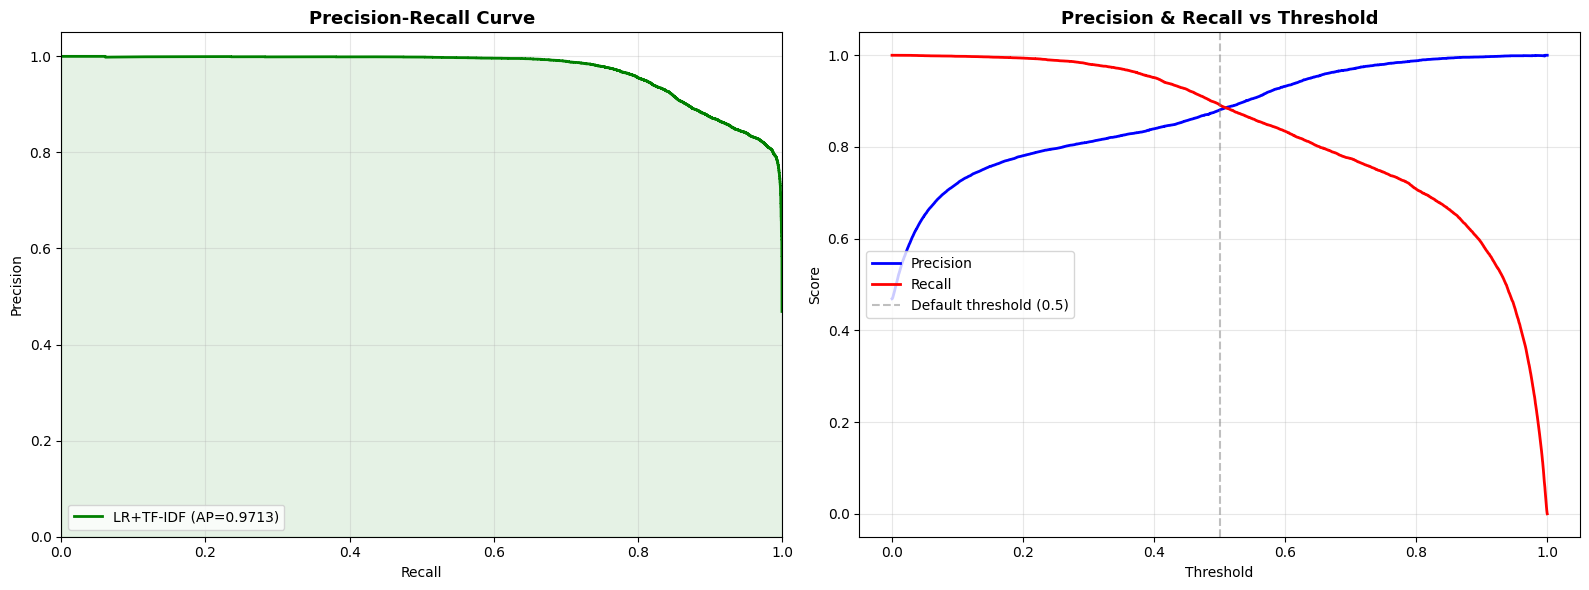

Average Precision (AP): 0.9713
→ AP càng cao (gần 1.0) = model phân loại tốt ở mọi ngưỡng.


In [19]:
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, y_prob[:, 1])
avg_precision = average_precision_score(y_test, y_prob[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curve
axes[0].plot(rec_curve, prec_curve, 'g-', linewidth=2,
             label=f'LR+TF-IDF (AP={avg_precision:.4f})')
axes[0].fill_between(rec_curve, prec_curve, alpha=0.1, color='green')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Precision & Recall vs Threshold
axes[1].plot(thresholds_pr, prec_curve[:-1], 'b-', linewidth=2, label='Precision')
axes[1].plot(thresholds_pr, rec_curve[:-1], 'r-', linewidth=2, label='Recall')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold', fontweight='bold', fontsize=13)
axes[1].legend(loc='center left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {avg_precision:.4f}')
print(f'→ AP càng cao (gần 1.0) = model phân loại tốt ở mọi ngưỡng.')


## 8. Đánh giá trên Validation Set (kiểm tra Overfitting)

So sánh performance trên Train, Val, Test để xác nhận mô hình không bị overfit.
Nếu Train >> Val/Test thì mô hình có dấu hiệu overfitting.


In [20]:
# Predictions trên từng tập
y_train_pred = lr_model.predict(X_train_tfidf)
y_val_pred = lr_model.predict(X_val_tfidf)

# Tính metrics cho từng tập
sets_eval = {
    'Train': (y_train, y_train_pred),
    'Val':   (y_val, y_val_pred),
    'Test':  (y_test, y_pred),
}

print('\n' + '=' * 70)
print('  OVERFITTING CHECK: Train vs Val vs Test')
print('=' * 70)
print(f'{"Set":>8s} | {"Accuracy":>10s} | {"Precision":>10s} | {"Recall":>10s} | {"F1":>10s}')
print('-' * 60)

overfit_data = {}
for name, (y_true, y_p) in sets_eval.items():
    acc = accuracy_score(y_true, y_p)
    prec = precision_score(y_true, y_p)
    rec = recall_score(y_true, y_p)
    f1_s = f1_score(y_true, y_p)
    print(f'{name:>8s} | {acc:>10.4f} | {prec:>10.4f} | {rec:>10.4f} | {f1_s:>10.4f}')
    overfit_data[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1_s}

# Phân tích chênh lệch
train_acc = overfit_data['Train']['accuracy']
val_acc = overfit_data['Val']['accuracy']
test_acc = overfit_data['Test']['accuracy']
gap_train_val = train_acc - val_acc
gap_train_test = train_acc - test_acc

print(f'\n--- Phân tích Overfitting ---')
print(f'  Gap (Train - Val):  {gap_train_val:+.4f}')
print(f'  Gap (Train - Test): {gap_train_test:+.4f}')

if gap_train_val > 0.05:
    print('  [WARNING] Có dấu hiệu overfitting (gap > 5%)')
elif gap_train_val > 0.02:
    print('  ⚡ Overfitting nhẹ (gap 2-5%), có thể chấp nhận được')
else:
    print('  [OK] Không có dấu hiệu overfitting (gap < 2%)')



  OVERFITTING CHECK: Train vs Val vs Test
     Set |   Accuracy |  Precision |     Recall |         F1
------------------------------------------------------------
   Train |     0.9156 |     0.9063 |     0.9145 |     0.9104
     Val |     0.8907 |     0.8789 |     0.8895 |     0.8842
    Test |     0.8926 |     0.8807 |     0.8918 |     0.8862

--- Phân tích Overfitting ---
  Gap (Train - Val):  +0.0248
  Gap (Train - Test): +0.0229
  ⚡ Overfitting nhẹ (gap 2-5%), có thể chấp nhận được


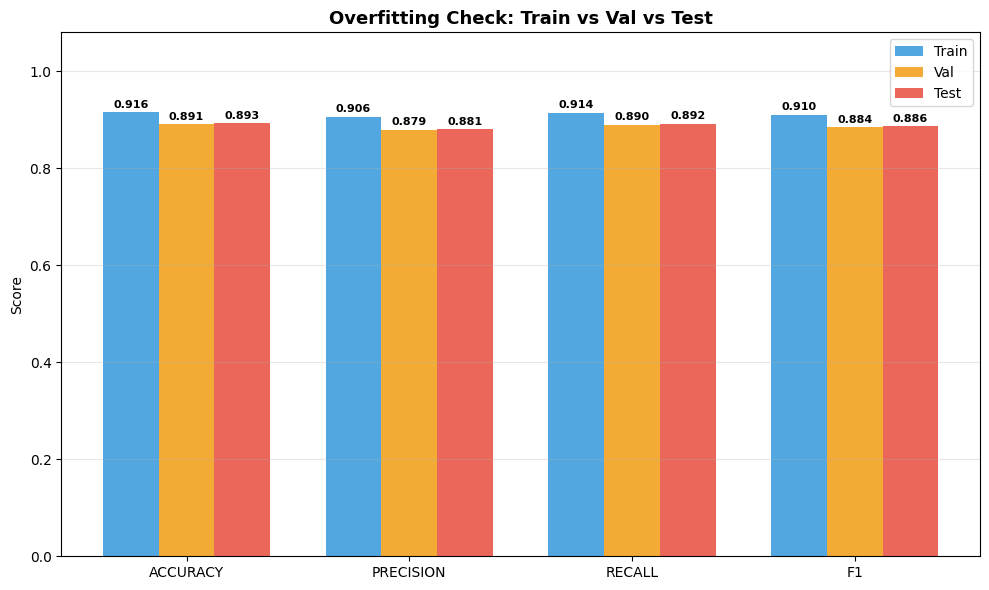

In [21]:
# Visualization: so sánh Train vs Val vs Test
fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_names))
width = 0.25
colors = ['#3498db', '#f39c12', '#e74c3c']

for i, (name, data) in enumerate(overfit_data.items()):
    vals = [data[m] for m in metrics_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics_names])
ax.set_ylabel('Score')
ax.set_title('Overfitting Check: Train vs Val vs Test', fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Top TF-IDF Features


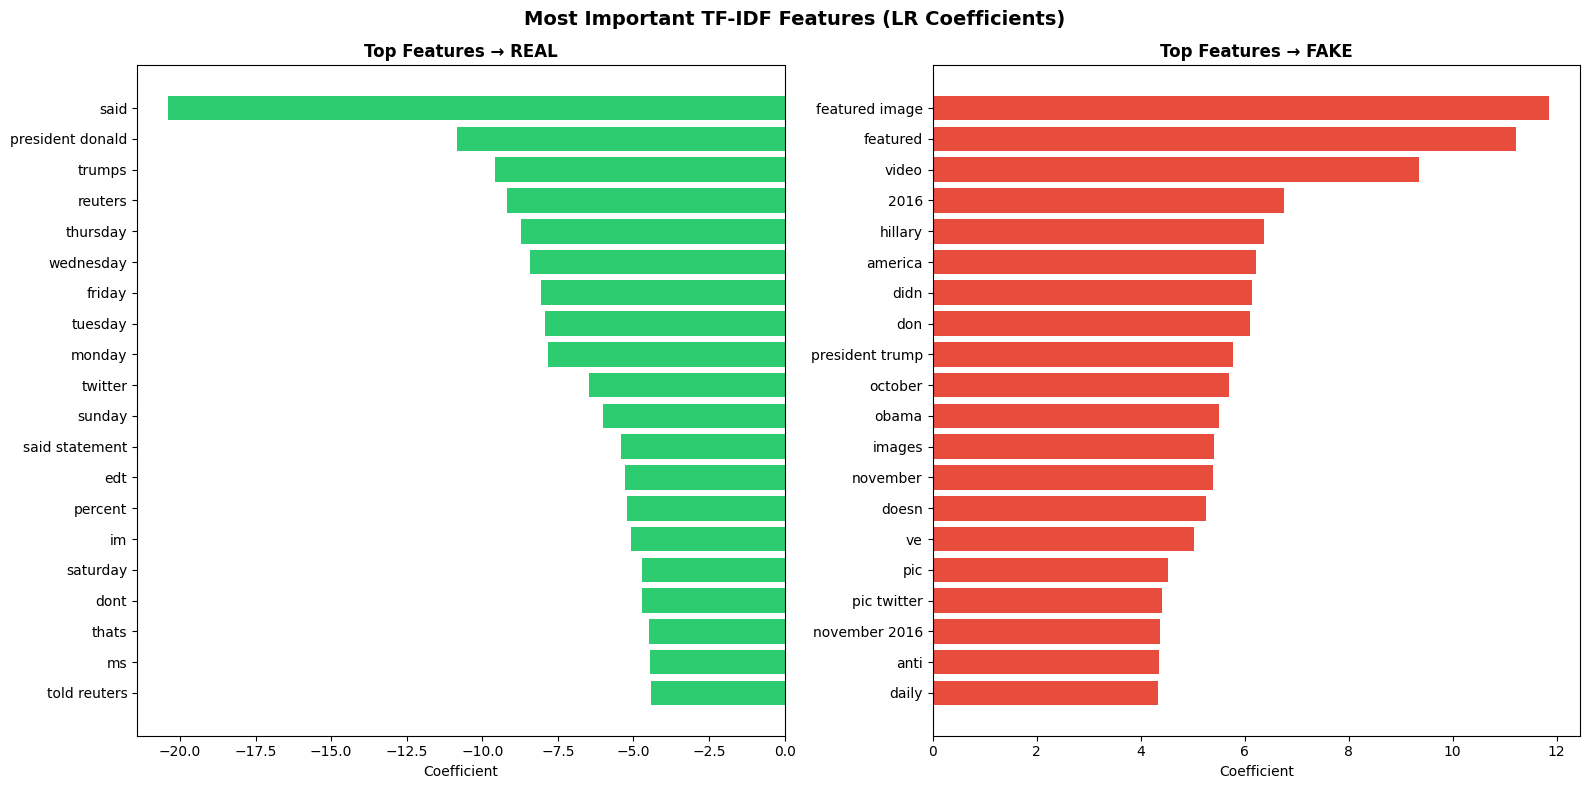

In [22]:
# Most important features for each class
feature_names = tfidf.get_feature_names_out()
coef = lr_model.coef_[0]

top_k = 20
top_fake = np.argsort(coef)[-top_k:][::-1]
top_real = np.argsort(coef)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(top_k), [coef[i] for i in reversed(top_real)], color='#2ecc71')
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([feature_names[i] for i in reversed(top_real)])
axes[0].set_title('Top Features → REAL', fontweight='bold')
axes[0].set_xlabel('Coefficient')

axes[1].barh(range(top_k), [coef[i] for i in reversed(top_fake)], color='#e74c3c')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([feature_names[i] for i in reversed(top_fake)])
axes[1].set_title('Top Features → FAKE', fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Most Important TF-IDF Features (LR Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Error Analysis

Phân tích các trường hợp model dự đoán sai để hiểu điểm yếu của baseline:
- **False Positives (FP)**: Real news bị dự đoán sai thành Fake
- **False Negatives (FN)**: Fake news bị dự đoán sai thành Real

Phân tích này giúp giải thích tại sao cần mô hình mạnh hơn như RoBERTa.


In [23]:
# Tìm các trường hợp dự đoán sai
wrong_mask = y_pred != y_test
fp_mask = (y_pred == 1) & (y_test == 0)  # Real bị đoán Fake
fn_mask = (y_pred == 0) & (y_test == 1)  # Fake bị đoán Real

print(f'=== Error Analysis ===')
print(f'  Total test samples:   {len(y_test):,}')
print(f'  Correct predictions:  {(~wrong_mask).sum():,} ({(~wrong_mask).mean()*100:.1f}%)')
print(f'  Wrong predictions:    {wrong_mask.sum():,} ({wrong_mask.mean()*100:.1f}%)')
print(f'    - False Positives:  {fp_mask.sum():,} (Real → Fake)')
print(f'    - False Negatives:  {fn_mask.sum():,} (Fake → Real)')


=== Error Analysis ===
  Total test samples:   20,405
  Correct predictions:  18,214 (89.3%)
  Wrong predictions:    2,191 (10.7%)
    - False Positives:  1,156 (Real → Fake)
    - False Negatives:  1,035 (Fake → Real)


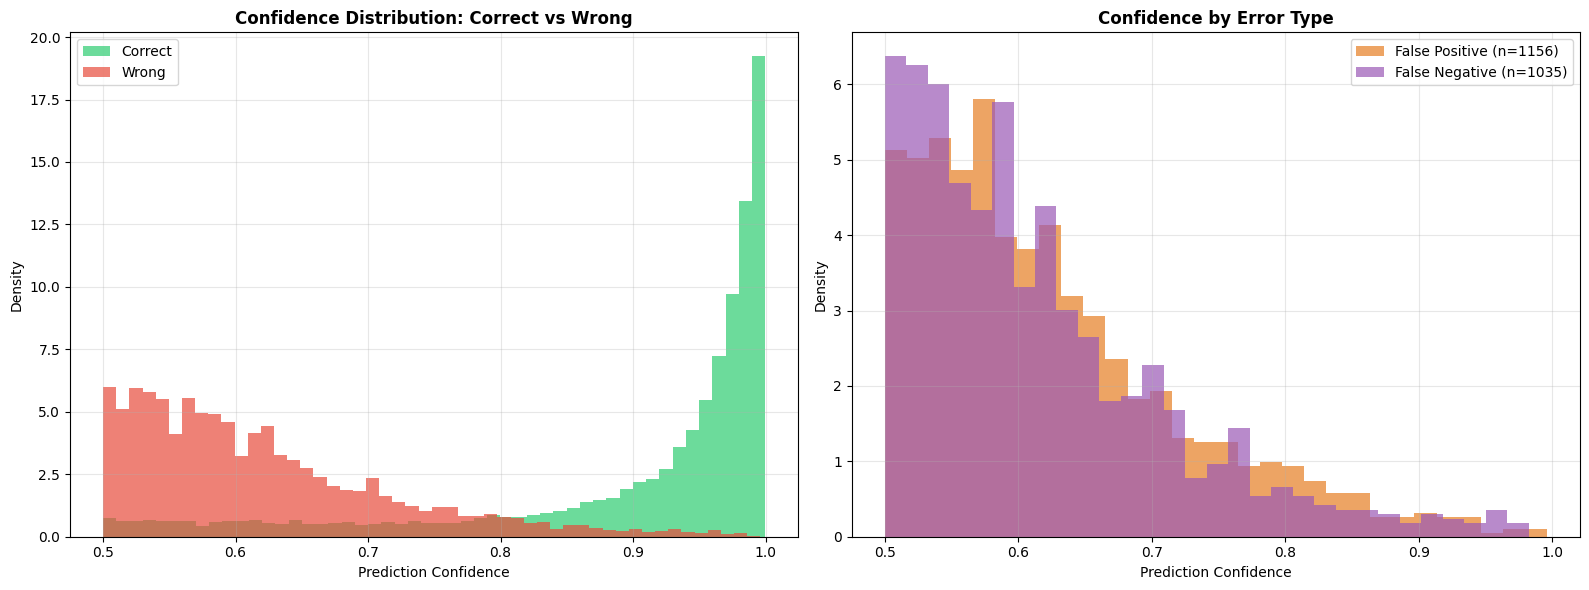


--- Confidence Statistics ---
  Correct predictions — mean confidence: 0.8991
  Wrong predictions   — mean confidence: 0.6198
  False Positives     — mean confidence: 0.6241
  False Negatives     — mean confidence: 0.6149


In [24]:
# Phân tích confidence của các trường hợp sai
wrong_probs = y_prob[wrong_mask]
correct_probs = y_prob[~wrong_mask]

wrong_confidence = wrong_probs.max(axis=1)
correct_confidence = correct_probs.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phân phối confidence
axes[0].hist(correct_confidence, bins=50, alpha=0.7, label='Correct', color='#2ecc71', density=True)
axes[0].hist(wrong_confidence, bins=50, alpha=0.7, label='Wrong', color='#e74c3c', density=True)
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Density')
axes[0].set_title('Confidence Distribution: Correct vs Wrong', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phân phối confidence theo loại lỗi
if fp_mask.sum() > 0:
    fp_conf = y_prob[fp_mask].max(axis=1)
    axes[1].hist(fp_conf, bins=30, alpha=0.7, label=f'False Positive (n={fp_mask.sum()})',
                 color='#e67e22', density=True)
if fn_mask.sum() > 0:
    fn_conf = y_prob[fn_mask].max(axis=1)
    axes[1].hist(fn_conf, bins=30, alpha=0.7, label=f'False Negative (n={fn_mask.sum()})',
                 color='#9b59b6', density=True)
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence by Error Type', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n--- Confidence Statistics ---')
print(f'  Correct predictions — mean confidence: {correct_confidence.mean():.4f}')
print(f'  Wrong predictions   — mean confidence: {wrong_confidence.mean():.4f}')
if fp_mask.sum() > 0:
    print(f'  False Positives     — mean confidence: {fp_conf.mean():.4f}')
if fn_mask.sum() > 0:
    print(f'  False Negatives     — mean confidence: {fn_conf.mean():.4f}')


In [25]:
# Hiển thị một số ví dụ dự đoán sai
error_df = test_df[wrong_mask].copy()
error_df['predicted'] = y_pred[wrong_mask]
error_df['true_label'] = y_test[wrong_mask]
error_df['confidence'] = y_prob[wrong_mask].max(axis=1)
error_df['error_type'] = np.where(error_df['predicted'] == 1, 'FP (Real→Fake)', 'FN (Fake→Real)')

# Sắp xếp theo confidence giảm dần (high-confidence errors nghiêm trọng hơn)
error_df = error_df.sort_values('confidence', ascending=False)

print('=== Top 5 High-Confidence ERRORS (mô hình tự tin nhưng sai) ===')
print('Đây là các trường hợp nghiêm trọng nhất — mô hình rất tự tin nhưng dự đoán sai.\n')
for i, (_, row) in enumerate(error_df.head(5).iterrows()):
    text_preview = str(row['text'])[:200] + '...' if len(str(row['text'])) > 200 else str(row['text'])
    print(f'--- Error #{i+1} ---')
    print(f'  Type:       {row["error_type"]}')
    print(f'  Confidence: {row["confidence"]:.4f}')
    print(f'  Text:       {text_preview}')
    print()

# Thống kê theo độ dài text
error_df['text_len'] = error_df['text'].astype(str).apply(len)
correct_df_temp = test_df[~wrong_mask].copy()
correct_df_temp['text_len'] = correct_df_temp['text'].astype(str).apply(len)

print(f'\n--- Text Length Analysis ---')
print(f'  Correct predictions — mean text length: {correct_df_temp["text_len"].mean():.0f} chars')
print(f'  Wrong predictions   — mean text length: {error_df["text_len"].mean():.0f} chars')
print(f'\n→ Baseline LR+TF-IDF dựa vào bag-of-words, không hiểu context/semantics.')
print(f'→ Đây là lý do cần RoBERTa để nắm bắt ngữ cảnh sâu hơn.')


=== Top 5 High-Confidence ERRORS (mô hình tự tin nhưng sai) ===
Đây là các trường hợp nghiêm trọng nhất — mô hình rất tự tin nhưng dự đoán sai.

--- Error #1 ---
  Type:       FP (Real→Fake)
  Confidence: 0.9960
  Text:       Reporter: Mr. President, when did you first learn that Hillary Clinton used an email system outside the U.S. government for official business when she was Secretary of State? POTUS: The same time as e...

--- Error #2 ---
  Type:       FP (Real→Fake)
  Confidence: 0.9824
  Text:       The tagline for the 2016 GOP race might as well be, Make America Misogynist Again. On Wednesday night, Donald Trump and Ted Cruz got into a Twitter spat. After a conservative anti-Trump SuperPAC ran a...

--- Error #3 ---
  Type:       FN (Fake→Real)
  Confidence: 0.9824
  Text:       IS OBAMAS RADICAL AGENDA Responsible For State Departments Misleading Report On Forced Labor, Prostitution And Human Slavery? President Barack Obama has called the fight against human trafficking one ..

## 11. Save Model & Results


In [26]:
# Save model
os.makedirs(BASELINE_MODEL_DIR, exist_ok=True)
with open(os.path.join(BASELINE_MODEL_DIR, 'lr_model.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)
with open(os.path.join(BASELINE_MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

# Save results — ĐẦY ĐỦ precision và recall cho notebook 05
baseline_results = {
    'model': 'LR + TF-IDF',
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'roc_auc': float(roc_auc),
    'average_precision': float(avg_precision),
    'train_time_seconds': float(train_time),
    'cross_validation': {
        'cv_folds': 5,
        'accuracy_mean': float(cv_accuracy.mean()),
        'accuracy_std': float(cv_accuracy.std()),
        'f1_mean': float(cv_f1.mean()),
        'f1_std': float(cv_f1.std()),
        'precision_mean': float(cv_precision.mean()),
        'precision_std': float(cv_precision.std()),
        'recall_mean': float(cv_recall.mean()),
        'recall_std': float(cv_recall.std()),
    },
    'overfitting_check': {
        'train_accuracy': float(overfit_data['Train']['accuracy']),
        'val_accuracy': float(overfit_data['Val']['accuracy']),
        'test_accuracy': float(overfit_data['Test']['accuracy']),
        'gap_train_val': float(gap_train_val),
        'gap_train_test': float(gap_train_test),
    },
    'error_analysis': {
        'total_errors': int(wrong_mask.sum()),
        'false_positives': int(fp_mask.sum()),
        'false_negatives': int(fn_mask.sum()),
        'mean_confidence_correct': float(correct_confidence.mean()),
        'mean_confidence_wrong': float(wrong_confidence.mean()),
    },
    'tfidf_config': {
        'max_features': TFIDF_MAX_FEATURES,
        'ngram_range': list(TFIDF_NGRAM_RANGE),
        'stop_words': 'english',
        'sublinear_tf': True,
        'min_df': 2,
        'max_df': 0.95
    }
}
save_metrics(baseline_results, os.path.join(RESULTS_DIR, 'baseline_results.json'))

print('\n[OK] Model saved to:', BASELINE_MODEL_DIR)
print('[OK] Results saved to:', RESULTS_DIR)
print('\n--- Saved metrics include ---')
for key in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']:
    print(f'  {key}: {baseline_results[key]:.4f}')


[OK] Metrics saved to: d:\Fake_news_RoBERTa\results\baseline_results.json

[OK] Model saved to: d:\Fake_news_RoBERTa\models\baseline
[OK] Results saved to: d:\Fake_news_RoBERTa\results

--- Saved metrics include ---
  accuracy: 0.8926
  precision: 0.8807
  recall: 0.8918
  f1: 0.8862
  roc_auc: 0.9736
  average_precision: 0.9713


## Summary

### Kết quả Baseline LR + TF-IDF:
- Mô hình sử dụng TF-IDF (bag-of-words) + Logistic Regression
- Cross-validation xác nhận mô hình ổn định
- Đánh giá đầy đủ: Accuracy, Precision, Recall, F1, ROC AUC, PR AUC
- Kiểm tra overfitting qua so sánh Train/Val/Test
- Error analysis cho thấy hạn chế của phương pháp bag-of-words

### Hạn chế của Baseline:
- Không nắm bắt được ngữ cảnh (context) của văn bản
- Phụ thuộc vào từ khóa, không hiểu ngữ nghĩa (semantics)
- Dễ bị đánh lừa bởi fake news viết tinh vi (dùng từ ngữ giống real news)

→ **Đây là lý do cần RoBERTa** (contextual embeddings) để cải thiện performance.

### Tiếp theo:
- **Notebook 04**: Train RoBERTa fine-tuned trên news domain
- **Notebook 05**: So sánh baseline vs RoBERTa (Experiment 1)
